In [40]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import models,layers,Sequential
import numpy as np

In [2]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
EPOCH = 15
TRIAN_SIZE = .8
VALIDATION_TEST = .10
TEST_SIZE = .10

In [3]:

data = tf.keras.preprocessing.image_dataset_from_directory('PlantVillage',shuffle=True,image_size=(IMAGE_SIZE,IMAGE_SIZE),batch_size=BATCH_SIZE)

Found 2152 files belonging to 3 classes.


In [4]:
class_name = data.class_names

In [5]:
print(f'class names {class_name}')
print(f'length of dataset {len(data)}')

class names ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
length of dataset 68


In [6]:
for image_batch,label_batch in data.take(1):
    print(image_batch.shape)
    print(label_batch)

(32, 256, 256, 3)
tf.Tensor([0 0 1 1 1 1 0 1 0 1 0 1 1 0 0 1 1 1 1 0 0 1 0 1 1 1 1 1 2 2 0 0], shape=(32,), dtype=int32)


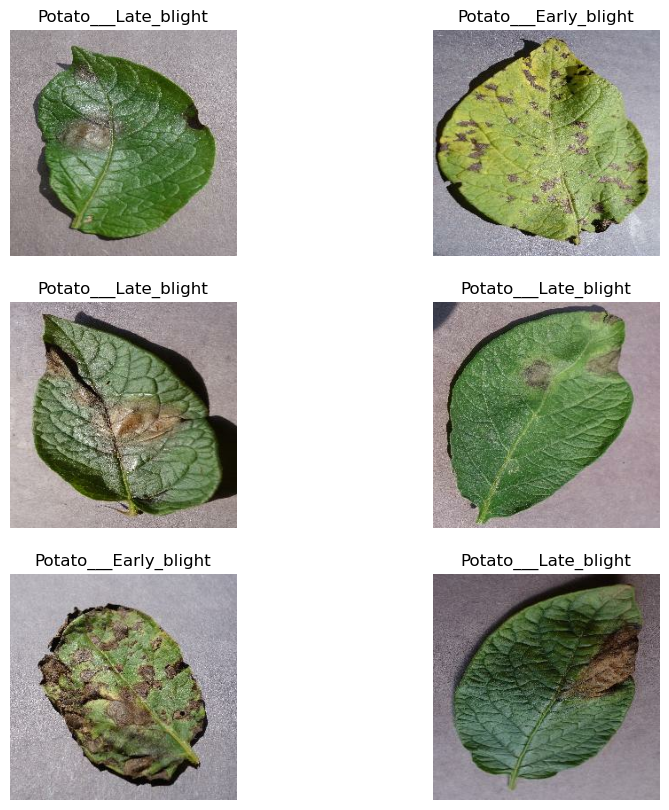

In [7]:
plt.figure(figsize=(10,10))
for image_batch,label_batch in data.take(1):
    for i in range(6):
      ax = plt.subplot(3,2,i+1)
      plt.imshow(image_batch[i].numpy().astype('uint8'))
      plt.axis('off')
      plt.title(class_name[label_batch[i]])

In [8]:
TRIAN_SIZE = int(len(data)*TRIAN_SIZE)
# its 54 so we use that size as a trining size
train_data = data.take(TRIAN_SIZE)
len(train_data)
test_and_validation = data.skip(58)
VALIDATION_TEST = int(len(data)*.1)
VALIDATION_data = test_and_validation.take(VALIDATION_TEST)
test_data = test_and_validation.skip(6)


In [9]:
train_data = train_data
val_data = VALIDATION_data
test_data = test_data

In [10]:
len(train_data)

54

In [11]:
len(val_data)

6

In [12]:
len(test_data)

4

In [13]:
train_data = train_data.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_data = test_data.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_data = val_data.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [14]:
resize_and_rescale = tf.keras.Sequential([
    layers.Rescaling(1.0/255),
    layers.Resizing(256,256)
    

])

In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomContrast(0.2),
    layers.RandomZoom(height_factor=(-0.2,0.2),width_factor=(-0.2,0.2))
])

In [16]:
Chneels=3
INPUT_SHAPE = (BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE,Chneels)
model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32,(3,3),activation='relu',input_shape=INPUT_SHAPE),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPool2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(3,activation='softmax')


])
model.build(input_shape=INPUT_SHAPE)

c:\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 125, 125, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 62, 62, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 60, 60, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 30, 30, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (32, 28800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │     1,843,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,862,851 (7.11 MB)

 Trainable params: 1,862,851 (7.11 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),metrics=['accuracy'])
history = model.fit(train_data,epochs=EPOCH,batch_size=BATCH_SIZE,verbose=1,validation_data=val_data)

Epoch 1/15


54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 694ms/step - accuracy: 0.9531 - loss: 0.1259 - val_accuracy: 0.9740 - val_loss: 0.0746
Epoch 2/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 36s 676ms/step - accuracy: 0.9688 - loss: 0.0814 - val_accuracy: 0.9792 - val_loss: 0.0572
Epoch 3/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 643ms/step - accuracy: 0.9670 - loss: 0.0926 - val_accuracy: 0.9896 - val_loss: 0.0262
Epoch 4/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 650ms/step - accuracy: 0.9630 - loss: 0.1038 - val_accuracy: 0.9948 - val_loss: 0.0324
Epoch 5/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 34s 634ms/step - accuracy: 0.9740 - loss: 0.0665 - val_accuracy: 0.9896 - val_loss: 0.0365
Epoch 6/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 34s 620ms/step - accuracy: 0.9751 - loss: 0.0699 - val_accuracy: 0.9792 - val_loss: 0.0327
Epoch 7/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 33s 619ms/step - accuracy: 0.9595 - loss: 0.1065 - val_accuracy: 0.9635 - val_loss: 0.1062
Epoch 8/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 35s 657ms/step - accuracy: 0.9751 - loss: 0.0660 - val_accuracy: 0.974

In [19]:
model.evaluate(test_data)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - loss: 0.1273


0.1272510439157486

In [22]:
history 

In [23]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [24]:
acc = history.history['accuracy']
loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

Text(0.5, 1.0, 'training and validation accuracy')

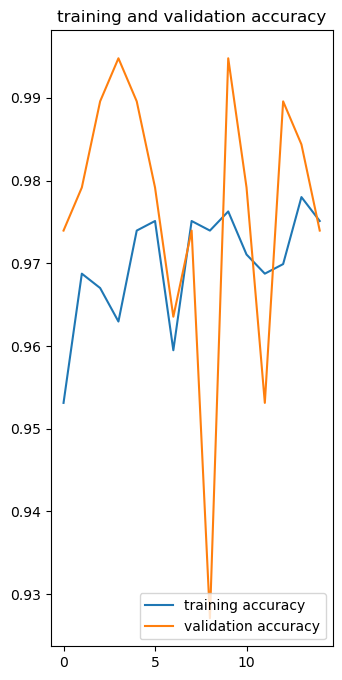

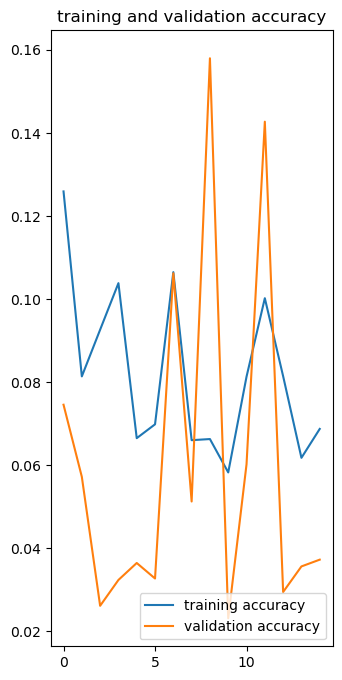

In [27]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(15),acc,label='training accuracy')
plt.plot(range(15),val_acc,label='validation accuracy'),
plt.legend(loc='lower right')
plt.title("training and validation accuracy")


plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(15),loss,label='training accuracy')
plt.plot(range(15),val_loss,label='validation accuracy'),
plt.legend(loc='lower right')
plt.title("training and validation accuracy")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
Potato___healthy


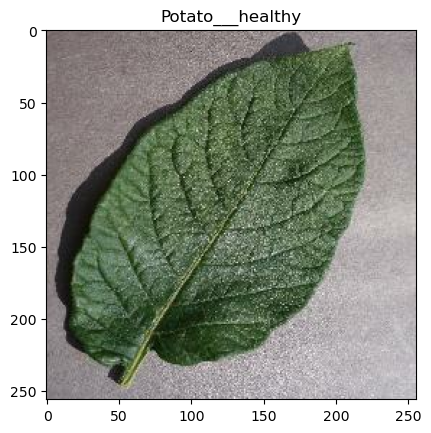

In [62]:
label_list = []

for image_batcc,label_batch in data.take(1):
        plt.imshow(image_batcc[1].numpy().astype('uint8'))
        plt.title(class_name[label_batch[1]])
        
        predicted_image_batch = model.predict(image_batcc)
        print(class_name[np.argmax(predicted_image_batch[1])])
        



In [ ]:
import os
model_version = 1
model.save(f'{model_version}.keras')